In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

In [14]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
col_names = ['sepal.length', 'sepal.width',	'petal.length',	'petal.width',	'variety'] 

df = pd.read_csv(url, names=col_names, header=None, skiprows=1)

display(df.head())

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [25]:
X = df.drop('variety', axis=1)
y = df['variety']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [26]:
svm = SVC(probability=True, random_state=42)
param_grid = {
    'C' : [0.1, 1, 10, 100],
    'kernel' : ['linear', 'rbf', 'poly'],
    'degree' : [2, 3, 4],
    'gamma' : ['scale', 'auto']
}

grid_search = GridSearchCV(estimator=svm, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print('Best Hyperparamter:', grid_search.best_params_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Hyperparamter: {'C': 1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}


              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        19
  Versicolor       1.00      0.92      0.96        13
   Virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



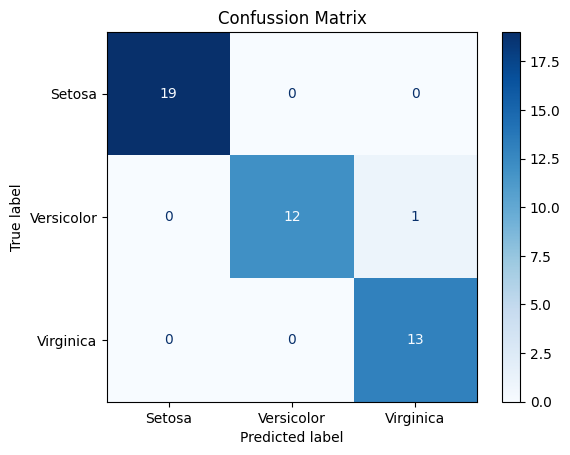

In [27]:
y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confussion Matrix')
plt.show
report = classification_report(y_test, y_pred, labels=best_model.classes_)
print(report)

<function matplotlib.pyplot.show(close=None, block=None)>

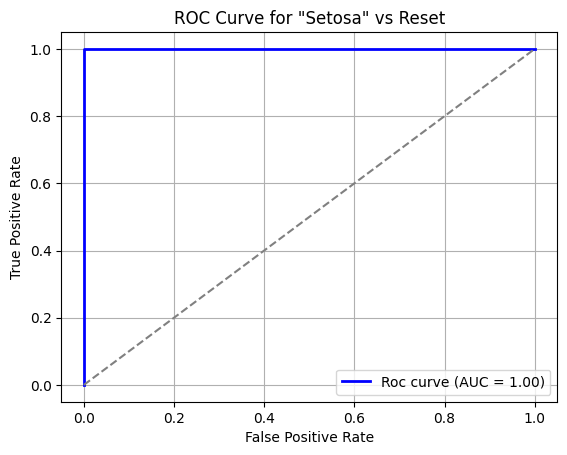

In [34]:
positive_class = 'Setosa'
y_test_binary = (y_test == positive_class).astype(int)
y_score = best_model.predict_proba(X_test)[:, list(best_model.classes_).index(positive_class)]

fpr, tpr, _ = roc_curve(y_test_binary, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Roc curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='gray', linestyle = '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve for "{positive_class}" vs Reset')
plt.legend(loc="lower right")
plt.grid(True)
plt.show